In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [3]:
from sklearn.datasets import fetch_openml
titanic = fetch_openml("titanic", version=1, as_frame=True)
df = titanic.frame.copy()
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

print("\nStatistical summary:")
display(df.describe(include="all"))

Shape: (1309, 14)

Columns:
['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest']

Data types:
pclass          int64
survived     category
name              str
sex          category
age           float64
sibsp           int64
parch           int64
ticket            str
fare          float64
cabin             str
embarked     category
boat              str
body          float64
home.dest         str
dtype: object

First 5 rows:


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"



Statistical summary:


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
count,1309.000000,1309,1309,1309,1046.000000,1309.000000,1309.000000,1309,1308.000000,295,1307,486,121.000000,745
unique,NaN,2,1307,2,NaN,NaN,NaN,929,NaN,186,3,27,NaN,369
top,NaN,0,"Connolly, Miss. Kate",male,NaN,NaN,NaN,CA. 2343,NaN,C23 C25 C27,S,13,NaN,"New York, NY"
freq,NaN,809,2,843,NaN,NaN,NaN,11,NaN,6,914,39,NaN,64
mean,2.294882,NaN,NaN,NaN,29.881135,0.498854,0.385027,NaN,33.295479,NaN,NaN,NaN,160.809917,NaN
std,0.837836,NaN,NaN,NaN,14.413500,1.041658,0.865560,NaN,51.758668,NaN,NaN,NaN,97.696922,NaN
min,1.000000,NaN,NaN,NaN,0.166700,0.000000,0.000000,NaN,0.000000,NaN,NaN,NaN,1.000000,NaN
25%,2.000000,NaN,NaN,NaN,21.000000,0.000000,0.000000,NaN,7.895800,NaN,NaN,NaN,72.000000,NaN
50%,3.000000,NaN,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN,NaN,155.000000,NaN
75%,3.000000,NaN,NaN,NaN,39.000000,1.000000,0.000000,NaN,31.275000,NaN,NaN,NaN,256.000000,NaN


In [5]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print("Missing values:")
display(missing)

Missing values:


body         1188
cabin        1014
boat          823
home.dest     564
age           263
embarked        2
fare            1
dtype: int64

In [6]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print("Missing values:")
display(missing)

Missing values:


body         1188
cabin        1014
boat          823
home.dest     564
age           263
embarked        2
fare            1
dtype: int64

In [7]:
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

print("Missing numerical values handled.")

Missing numerical values handled.


In [8]:
categorical_columns = df.select_dtypes(include=["object", "category"]).columns

for column in categorical_columns:
    if df[column].isnull().any():
        df[column] = df[column].fillna(df[column].mode()[0])

print("Missing categorical values handled.")

Missing categorical values handled.


C:\Users\dell\AppData\Local\Temp\ipykernel_22708\2848882581.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object", "category"]).columns


In [9]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

df_encoded.head()

,pclass,age,sibsp,parch,fare,body,survived_1,"name_Abbott, Master. Eugene Joseph","name_Abbott, Mr. Rossmore Edward","name_Abbott, Mrs. Stanton (Rosa Hunt)",...,"home.dest_Wimbledon Park, London / Hayling Island, Hants","home.dest_Windsor, England New York, NY","home.dest_Winnipeg, MB","home.dest_Winnipeg, MN","home.dest_Woodford County, KY","home.dest_Worcester, England","home.dest_Worcester, MA","home.dest_Yoevil, England / Cottage Grove, OR","home.dest_Youngstown, OH","home.dest_Zurich, Switzerland"
0,1,29.0000,0,0,211.3375,155.0,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1,0.9167,1,2,151.5500,155.0,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1,2.0000,1,2,151.5500,155.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1,30.0000,1,2,151.5500,135.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1,25.0000,1,2,151.5500,155.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [10]:
from sklearn.preprocessing import MinMaxScaler

numeric_columns = df_encoded.select_dtypes(
    include=np.number
).columns

scaler = MinMaxScaler()

df_encoded[numeric_columns] = scaler.fit_transform(
    df_encoded[numeric_columns]
)

df_encoded.head()

,pclass,age,sibsp,parch,fare,body,survived_1,"name_Abbott, Master. Eugene Joseph","name_Abbott, Mr. Rossmore Edward","name_Abbott, Mrs. Stanton (Rosa Hunt)",...,"home.dest_Wimbledon Park, London / Hayling Island, Hants","home.dest_Windsor, England New York, NY","home.dest_Winnipeg, MB","home.dest_Winnipeg, MN","home.dest_Woodford County, KY","home.dest_Worcester, England","home.dest_Worcester, MA","home.dest_Yoevil, England / Cottage Grove, OR","home.dest_Youngstown, OH","home.dest_Zurich, Switzerland"
0,0.0,0.361169,0.000,0.000000,0.412503,0.470948,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0.0,0.009395,0.125,0.222222,0.295806,0.470948,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0.0,0.022964,0.125,0.222222,0.295806,0.470948,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,0.0,0.373695,0.125,0.222222,0.295806,0.409786,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0.0,0.311064,0.125,0.222222,0.295806,0.470948,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


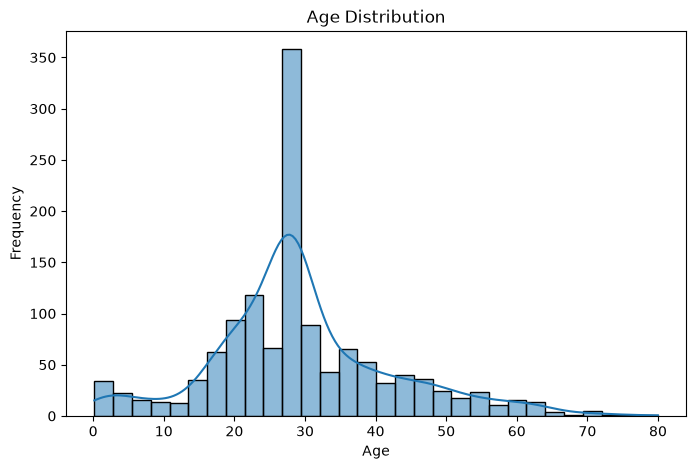

In [11]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["age"],
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

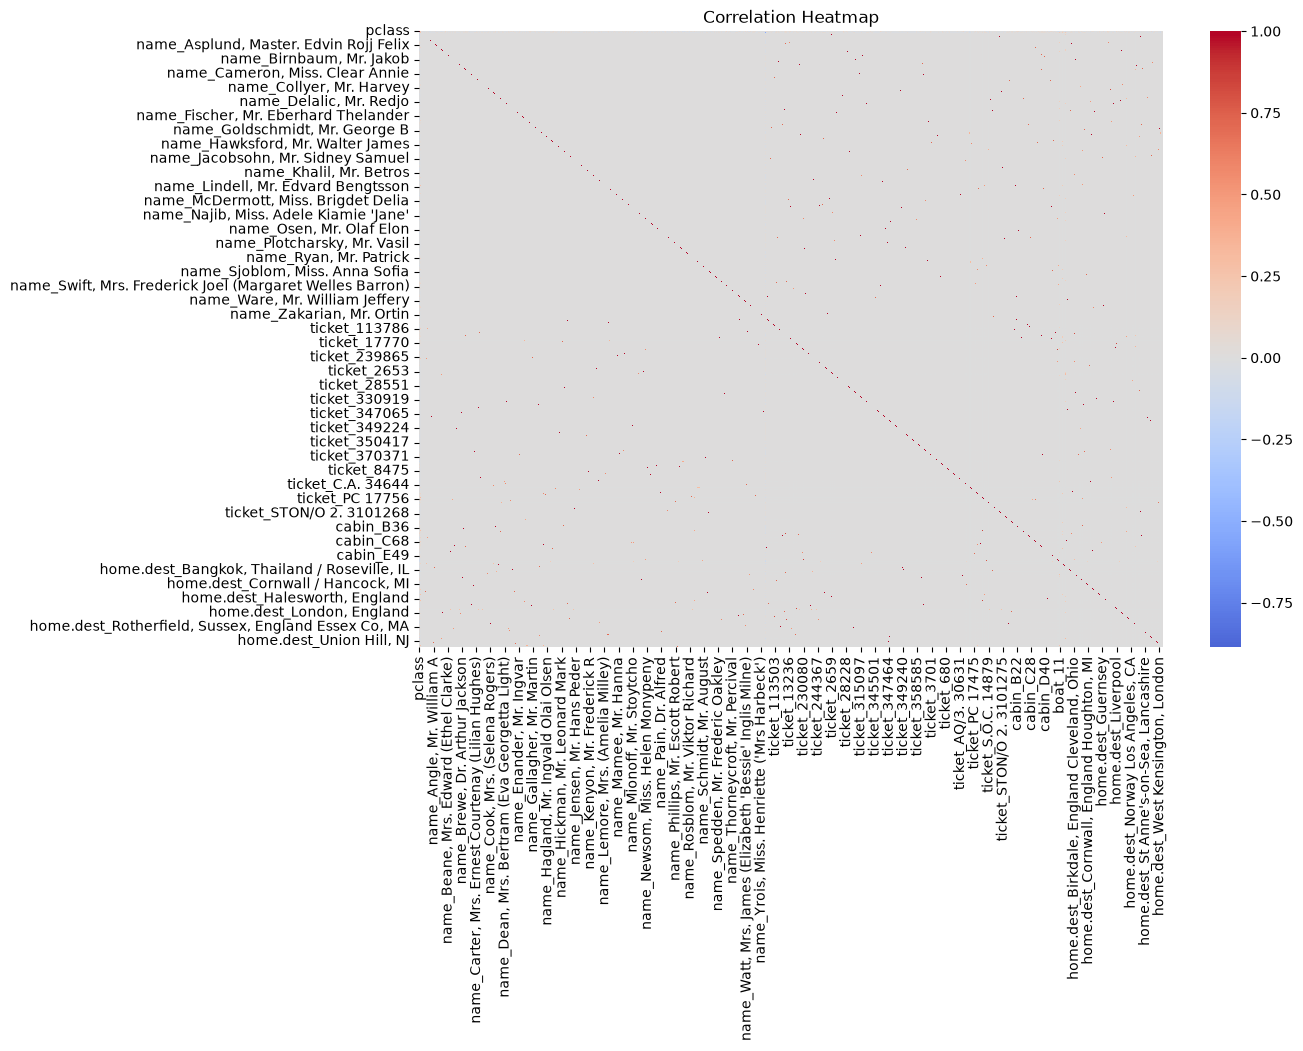

In [12]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df_encoded.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

In [13]:
print("Original shape:", titanic.frame.shape)
print("Processed shape:", df_encoded.shape)

print("\nRemaining missing values:")
print(df_encoded.isnull().sum().sum())

Original shape: (1309, 14)
Processed shape: (1309, 2823)

Remaining missing values:
0
